In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "FVs_medsiglip"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
print(meta_df.head())
print(meta_df["eye_DR_Level"].value_counts().sort_index())

X: (1189, 1152)
metadata: (1189, 12)
   patient_id image_id                           image_path  Overall quality  \
0           1     1_l1  \regular-fundus-training\1\1_l1.jpg                0   
1           1     1_l2  \regular-fundus-training\1\1_l2.jpg                0   
2           1     1_r1  \regular-fundus-training\1\1_r1.jpg                0   
3           1     1_r2  \regular-fundus-training\1\1_r2.jpg                0   
4           2     2_l1  \regular-fundus-training\2\2_l1.jpg                0   

   left_eye_DR_Level  right_eye_DR_Level  patient_DR_Level  Clarity  \
0                0.0                 NaN                 0        8   
1                0.0                 NaN                 0        8   
2                NaN                 0.0                 0        8   
3                NaN                 0.0                 0       10   
4                2.0                 NaN                 2       10   

   Field definition  Artifact eye  eye_DR_Level  
0    

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化
X_raw = X.copy() 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50
pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:
[0.16822945 0.12905145 0.08837747 0.07487845 0.0461589  0.03623527
 0.03451169 0.02874907 0.0254514  0.02157432]
Cumulative explained variance:
[0.16822945 0.2972809  0.38565838 0.46053684 0.50669575 0.542931
 0.5774427  0.60619175 0.6316432  0.6532175 ]


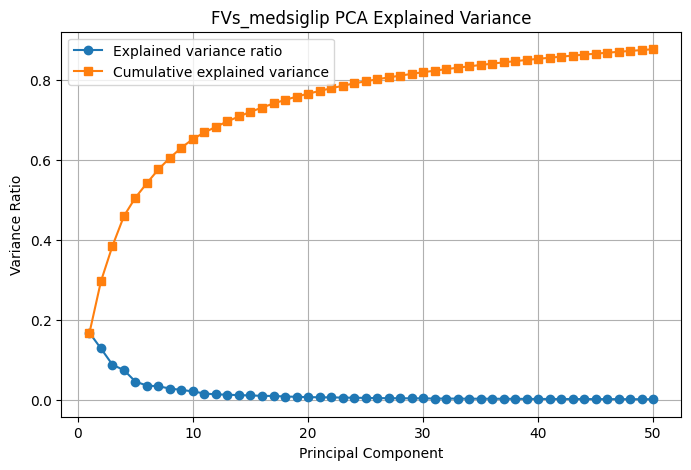

In [30]:
#医用基盤モデルの特徴空間には、少数の主要な方向により説明される構造が存在する。
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
pca_df = meta_df.copy()

for i in range(10):
    pca_df[f"PC{i+1}"] = Z[:, i]

print(pca_df[["image_id", "patient_id", "eye", "eye_DR_Level", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]].head())

  image_id  patient_id eye  eye_DR_Level        PC1        PC2        PC3  \
0     1_l1           1   l           0.0  10.376507 -15.733332   4.865417   
1     1_l2           1   l           0.0  22.613274 -17.682272  -1.757311   
2     1_r1           1   r           0.0  14.198502  16.576839  -4.113351   
3     1_r2           1   r           0.0  17.182337  18.487785   0.289808   
4     2_l1           2   l           2.0   2.134573  -2.781065 -10.176648   

        PC4        PC5       PC6       PC7       PC8       PC9      PC10  
0  3.534794   0.336087 -0.553500 -4.600570 -2.884047  4.879611  8.203623  
1  4.772875  -6.205924 -3.324574 -6.485861 -0.975414  3.164055 -3.579450  
2 -0.739971   3.196414 -6.387399 -4.990230  2.483158  4.048167  7.233805  
3  2.729641  -1.049126 -7.565164 -2.341928  1.342725  2.669397  3.896091  
4  6.195171  11.963681  3.814471  3.014484 -0.147059 -3.875123 -1.039365  


In [11]:
# 定义画图函数
def plot_pca_scatter(df, pc_x="PC1", pc_y="PC2", color_col="eye_DR_Level", title=None):
    plt.figure(figsize=(7, 6))
    
    labels = sorted(df[color_col].dropna().unique())
    
    for lab in labels:
        sub = df[df[color_col] == lab]
        plt.scatter(
            sub[pc_x],
            sub[pc_y],
            s=10,
            alpha=0.7,
            label=str(lab)
        )
    
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(title if title else f"{pc_x} vs {pc_y} colored by {color_col}")
    plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

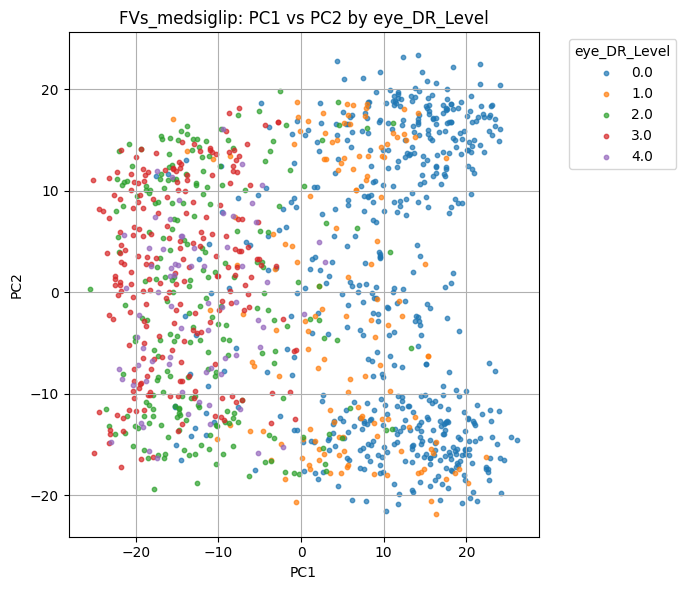

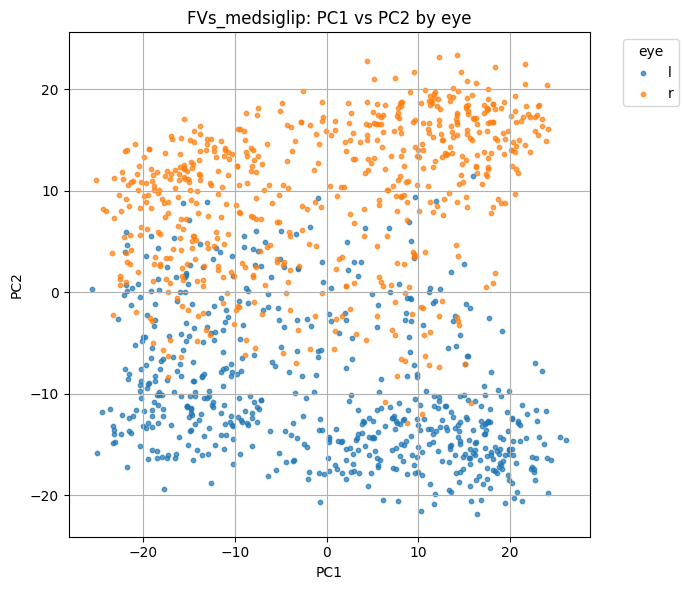

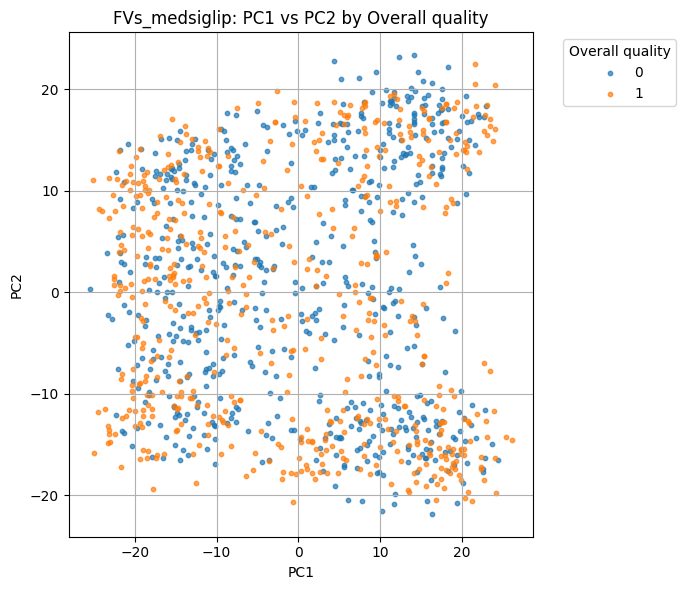

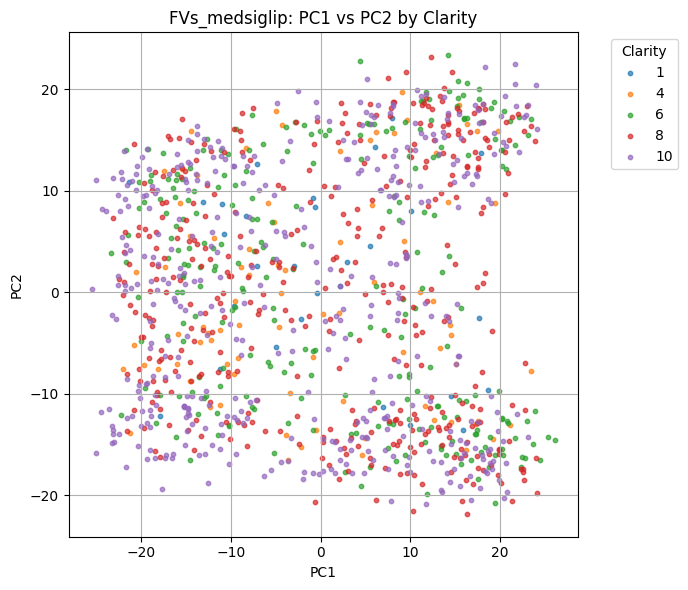

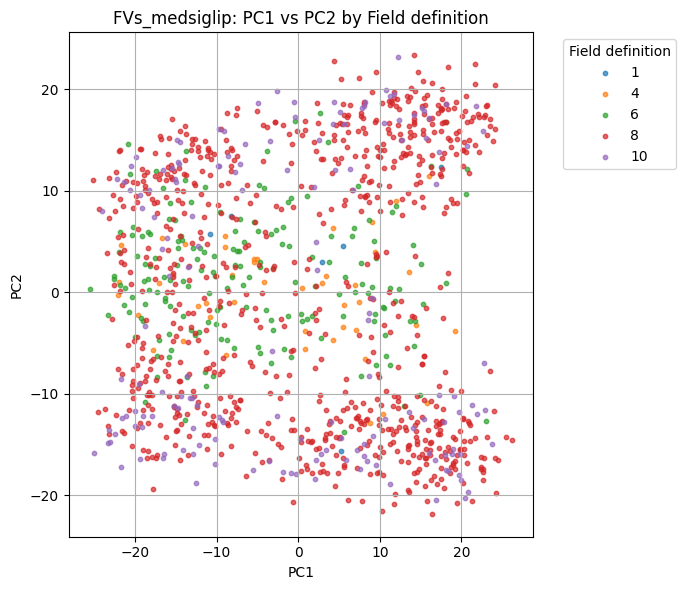

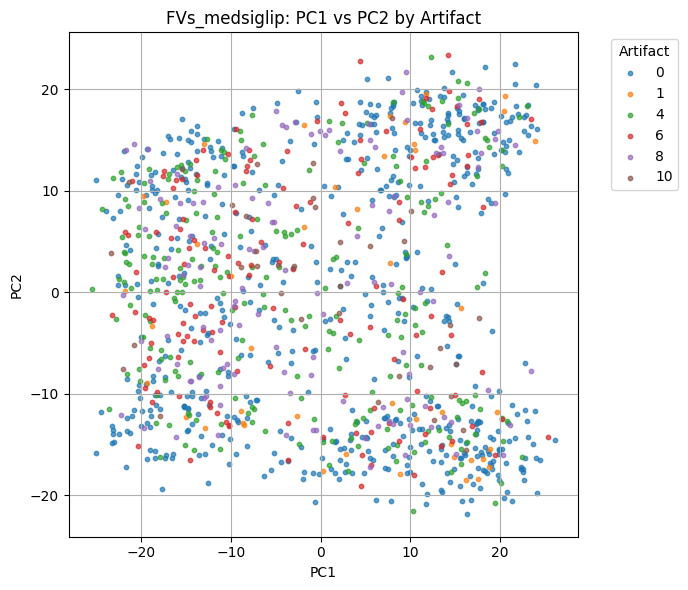

In [12]:
# 主成分1，2在各种成分上 的表现
plot_pca_scatter(pca_df, "PC1", "PC2", "eye_DR_Level", f"{model_name}: PC1 vs PC2 by eye_DR_Level")
plot_pca_scatter(pca_df, "PC1", "PC2", "eye", f"{model_name}: PC1 vs PC2 by eye")
plot_pca_scatter(pca_df, "PC1", "PC2", "Overall quality", f"{model_name}: PC1 vs PC2 by Overall quality")
plot_pca_scatter(pca_df, "PC1", "PC2", "Clarity", f"{model_name}: PC1 vs PC2 by Clarity")
plot_pca_scatter(pca_df, "PC1", "PC2", "Field definition", f"{model_name}: PC1 vs PC2 by Field definition")
plot_pca_scatter(pca_df, "PC1", "PC2", "Artifact", f"{model_name}: PC1 vs PC2 by Artifact")


In [13]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

rows = []

for i in range(10):
    pc = f"PC{i+1}"
    tmp = pca_df[[pc, "eye"]].dropna()
    
    y = (tmp["eye"] == "r").astype(int)
    score = tmp[pc].values
    
    auc = roc_auc_score(y, score)
    auc = max(auc, 1 - auc)  # 不管方向，只看分离强度
    
    left_vals = tmp[tmp["eye"] == "l"][pc]
    right_vals = tmp[tmp["eye"] == "r"][pc]
    
    cohen_d = abs(left_vals.mean() - right_vals.mean()) / np.sqrt(
        (left_vals.var() + right_vals.var()) / 2
    )
    
    rows.append({
        "PC": pc,
        "eye_AUC": auc,
        "cohen_d": cohen_d,
        "left_mean": left_vals.mean(),
        "right_mean": right_vals.mean()
    })

eye_pc_table = pd.DataFrame(rows).sort_values("eye_AUC", ascending=False)
eye_pc_table

,PC,eye_AUC,cohen_d,left_mean,right_mean
1,PC2,0.961727,2.780998,-9.909989,9.893334
8,PC9,0.523541,0.063261,0.171475,-0.171187
3,PC4,0.522168,0.086166,-0.400447,0.399774
9,PC10,0.519432,0.041710,-0.104120,0.103945
4,PC5,0.518343,0.063350,-0.231253,0.230864
2,PC3,0.511702,0.051228,-0.258796,0.258362
6,PC7,0.506907,0.025038,0.079065,-0.078933
7,PC8,0.503576,0.011566,0.033335,-0.033279
5,PC6,0.502453,0.007518,-0.024327,0.024286
0,PC1,0.502261,0.006108,0.042585,-0.042513


上位 10 主成分において、PC2 は左右眼情報を強く反映していた。PC2 単独による左右眼識別の AUC は 0.962、Cohen’s d は 2.78 であり、左眼と右眼の平均値もそれぞれ負方向・正方向に大きく分離していた。一方、その他の主成分では AUC がほぼ 0.5 に近く、左右眼情報は主に PC2 に集中していることが示唆された。

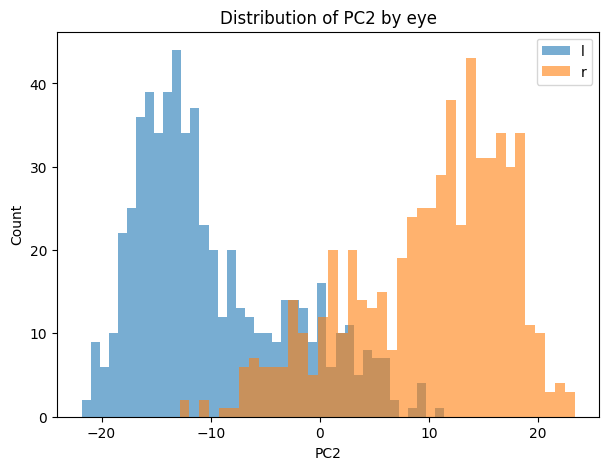

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for eye_value in ["l", "r"]:
    vals = pca_df[pca_df["eye"] == eye_value]["PC2"]
    plt.hist(vals, bins=40, alpha=0.6, label=eye_value)

plt.xlabel("PC2")
plt.ylabel("Count")
plt.title("Distribution of PC2 by eye")
plt.legend()
plt.show()

_现在的结论 PC2 编码 左右眼信息 （左眼集中在负方向，右眼集中在正方向）_

查看PC2是否携带了大量的grade 信息

In [ ]:
# 
grade_eye_dist = (
    pca_df
    .groupby("eye")["eye_DR_Level"]
    .value_counts(normalize=True)
    .unstack()
)

grade_eye_dist

eye_DR_Level,0.0,1.0,2.0,3.0,4.0
eye,,,,,
l,0.430976,0.129630,0.207071,0.161616,0.070707
r,0.463866,0.104202,0.183193,0.198319,0.050420


In [16]:
grade_eye_count = (
    pca_df
    .groupby("eye")["eye_DR_Level"]
    .value_counts()
    .unstack()
)

grade_eye_count

eye_DR_Level,0.0,1.0,2.0,3.0,4.0
eye,,,,,
l,256,77,123,96,42
r,276,62,109,118,30


In [17]:
pca_df[["PC2", "eye_DR_Level"]].dropna().corr(method="spearman")

,PC2,eye_DR_Level
PC2,1.000000,0.001229
eye_DR_Level,0.001229,1.000000


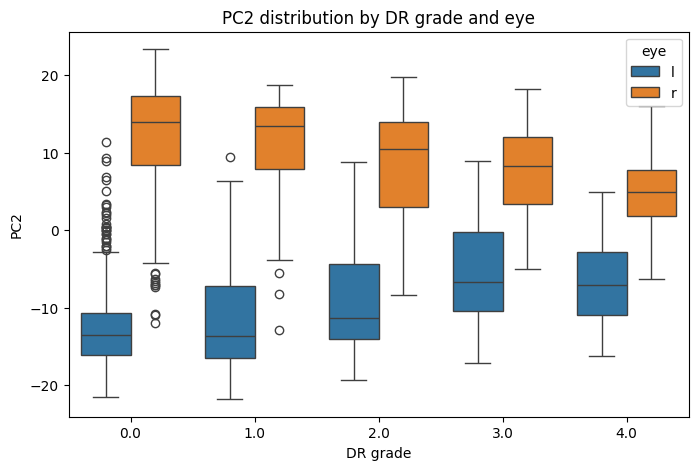

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pca_df,
    x="eye_DR_Level",
    y="PC2",
    hue="eye"
)

plt.title("PC2 distribution by DR grade and eye")
plt.xlabel("DR grade")
plt.ylabel("PC2")
plt.show()

左眼：grade 越高，PC2 似乎从很负的方向往 0 靠近；
右眼：grade 越高，PC2 似乎从很正的方向往 0 靠近。
PC2 主要编码左右眼信息；整体上 PC2 与 DR grade 的 Spearman 相关几乎为 0，但仍需要在左右眼分组内，或使用 |PC2|，进一步检查其是否受到 DR grade 影响。

In [19]:
for eye_value in ["l", "r"]:
    tmp = pca_df[pca_df["eye"] == eye_value][["PC2", "eye_DR_Level"]].dropna()
    corr = tmp.corr(method="spearman").iloc[0, 1]
    print(eye_value, corr)

l 0.3784018579623833
r -0.3435927117474439


In [20]:
pca_df["abs_PC2"] = pca_df["PC2"].abs()

pca_df[["abs_PC2", "eye_DR_Level"]].dropna().corr(method="spearman")

,abs_PC2,eye_DR_Level
abs_PC2,1.00000,-0.38183
eye_DR_Level,-0.38183,1.00000


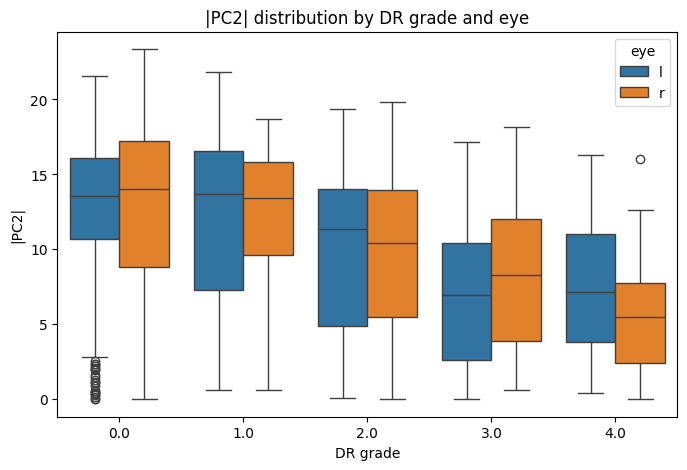

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pca_df,
    x="eye_DR_Level",
    y="abs_PC2",
    hue="eye"
)

plt.title("|PC2| distribution by DR grade and eye")
plt.xlabel("DR grade")
plt.ylabel("|PC2|")
plt.show()

PC2 的正负方向主要表示左右眼，但其幅度可能受到病变程度影响。也就是说，PC2 不是纯粹的 eye 信息，而是 eye 信息和图像病变状态有一定耦合。

尝试删除PC2 然后做对比

In [31]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    mean_absolute_error,
    roc_auc_score
)
import numpy as np
import pandas as pd

# ============================================================
# Strict CV evaluation: original vs remove_PC2
# scaler 和 PCA 都只在 train fold 上 fit
# ============================================================

mask = pca_df["eye_DR_Level"].notna()

X_use = X_raw[mask.values]
y_grade = pca_df.loc[mask, "eye_DR_Level"].astype(int).values
groups = pca_df.loc[mask, "patient_id"].values
y_eye = (pca_df.loc[mask, "eye"] == "r").astype(int).values

print("X_use shape:", X_use.shape)
print("Grade distribution:")
print(pd.Series(y_grade).value_counts().sort_index())

X_use shape: (1189, 1152)
Grade distribution:
0    532
1    139
2    232
3    214
4     72
Name: count, dtype: int64


In [32]:
def remove_pc_from_standardized_features(X_std, pca_model, pc_index):
    """
    在当前 fold 的 PCA 空间中删除指定 PC。
    
    X_std: 当前 fold 中已经用 train scaler 标准化后的特征
    pca_model: 只在 train fold 上 fit 的 PCA
    pc_index: 0-based index, PC2 -> 1
    """
    pc_score = pca_model.transform(X_std)[:, [pc_index]]
    X_removed = X_std - pc_score @ pca_model.components_[[pc_index]]
    return X_removed


def calc_metrics(y_true, y_pred, feature_name, fold):
    return {
        "fold": fold,
        "feature": feature_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "QWK": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [33]:
cv = GroupKFold(n_splits=5)

all_pred_original = np.zeros_like(y_grade)
all_pred_remove_pc2 = np.zeros_like(y_grade)

fold_results = []
pc2_eye_auc_records = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_use, y_grade, groups), start=1):
    
    X_train_raw = X_use[train_idx]
    X_test_raw = X_use[test_idx]
    
    y_train = y_grade[train_idx]
    y_test = y_grade[test_idx]
    
    eye_train = y_eye[train_idx]
    
    # ========================================================
    # 1. StandardScaler 只在 train fold 上 fit
    # ========================================================
    scaler_fold = StandardScaler()
    X_train_std = scaler_fold.fit_transform(X_train_raw)
    X_test_std = scaler_fold.transform(X_test_raw)
    
    # ========================================================
    # 2. original 特征分类器
    # ========================================================
    clf_original = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    )
    
    clf_original.fit(X_train_std, y_train)
    pred_original = clf_original.predict(X_test_std)
    
    all_pred_original[test_idx] = pred_original
    
    fold_results.append(
        calc_metrics(y_test, pred_original, "original", fold)
    )
    
    # ========================================================
    # 3. PCA 只在 train fold 上 fit
    # ========================================================
    n_components = min(50, X_train_std.shape[0] - 1, X_train_std.shape[1])
    
    pca_fold = PCA(n_components=n_components)
    pca_fold.fit(X_train_std)
    
    # 检查当前 fold 中 PC2 是否仍然编码 eye
    train_scores = pca_fold.transform(X_train_std)
    pc2_train_score = train_scores[:, 1]
    
    auc = roc_auc_score(eye_train, pc2_train_score)
    auc = max(auc, 1 - auc)
    
    pc2_eye_auc_records.append({
        "fold": fold,
        "train_PC2_eye_AUC": auc,
        "PC2_explained_var": pca_fold.explained_variance_ratio_[1]
    })
    
    # ========================================================
    # 4. 删除 PC2
    # ========================================================
    X_train_remove_pc2 = remove_pc_from_standardized_features(
        X_train_std,
        pca_fold,
        pc_index=1
    )
    
    X_test_remove_pc2 = remove_pc_from_standardized_features(
        X_test_std,
        pca_fold,
        pc_index=1
    )
    
    # sanity check: 删除后 PC2 score 是否接近 0
    removed_test_pc2_score = pca_fold.transform(X_test_remove_pc2)[:, 1]
    print(
        f"Fold {fold}: removed test PC2 std = {removed_test_pc2_score.std():.6f}, "
        f"max_abs = {np.abs(removed_test_pc2_score).max():.6f}"
    )
    
    # ========================================================
    # 5. remove_PC2 特征分类器
    # ========================================================
    clf_remove_pc2 = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    )
    
    clf_remove_pc2.fit(X_train_remove_pc2, y_train)
    pred_remove_pc2 = clf_remove_pc2.predict(X_test_remove_pc2)
    
    all_pred_remove_pc2[test_idx] = pred_remove_pc2
    
    fold_results.append(
        calc_metrics(y_test, pred_remove_pc2, "remove_PC2", fold)
    )

Fold 1: removed test PC2 std = 0.000012, max_abs = 0.000029
Fold 2: removed test PC2 std = 0.000016, max_abs = 0.000032
Fold 3: removed test PC2 std = 0.000003, max_abs = 0.000009
Fold 4: removed test PC2 std = 0.000003, max_abs = 0.000011
Fold 5: removed test PC2 std = 0.000012, max_abs = 0.000028


In [34]:
fold_results_df = pd.DataFrame(fold_results)
fold_results_df

,fold,feature,accuracy,balanced_acc,QWK,MAE
0,1,original,0.641667,0.509926,0.777085,0.479167
1,1,remove_PC2,0.654167,0.523889,0.799785,0.450000
2,2,original,0.718487,0.686174,0.834089,0.386555
3,2,remove_PC2,0.718487,0.686174,0.834089,0.386555
4,3,original,0.672269,0.637610,0.775981,0.457983
5,3,remove_PC2,0.693277,0.662217,0.813836,0.407563
6,4,original,0.683544,0.580303,0.785654,0.447257
7,4,remove_PC2,0.683544,0.559188,0.789314,0.438819
8,5,original,0.627119,0.595370,0.781053,0.483051
9,5,remove_PC2,0.644068,0.636111,0.796513,0.461864


In [35]:
summary_df = (
    fold_results_df
    .groupby("feature")[["accuracy", "balanced_acc", "QWK", "MAE"]]
    .agg(["mean", "std"])
)

summary_df

accuracy           balanced_acc                 QWK            \
                mean       std         mean       std      mean       std   
feature                                                                     
original    0.668617  0.035957     0.601877  0.065851  0.790772  0.024511   
remove_PC2  0.678709  0.030084     0.613516  0.069185  0.806708  0.017713   

                 MAE            
                mean       std  
feature                         
original    0.450803  0.038847  
remove_PC2  0.428960  0.031139

In [36]:
pc2_eye_auc_df = pd.DataFrame(pc2_eye_auc_records)
pc2_eye_auc_df

,fold,train_PC2_eye_AUC,PC2_explained_var
0,1,0.958059,0.127716
1,2,0.964989,0.131190
2,3,0.964153,0.130298
3,4,0.961872,0.128087
4,5,0.959084,0.128887


In [37]:
pc2_eye_auc_df.describe()

,fold,train_PC2_eye_AUC,PC2_explained_var
count,5.000000,5.000000,5.000000
mean,3.000000,0.961631,0.129236
std,1.581139,0.003039,0.001475
min,1.000000,0.958059,0.127716
25%,2.000000,0.959084,0.128087
50%,3.000000,0.961872,0.128887
75%,4.000000,0.964153,0.130298
max,5.000000,0.964989,0.131190


In [38]:
pivot_df = fold_results_df.pivot(index="fold", columns="feature", values=["accuracy", "balanced_acc", "QWK", "MAE"])

delta_df = pd.DataFrame({
    "delta_accuracy": pivot_df["accuracy"]["remove_PC2"] - pivot_df["accuracy"]["original"],
    "delta_balanced_acc": pivot_df["balanced_acc"]["remove_PC2"] - pivot_df["balanced_acc"]["original"],
    "delta_QWK": pivot_df["QWK"]["remove_PC2"] - pivot_df["QWK"]["original"],
    "delta_MAE": pivot_df["MAE"]["remove_PC2"] - pivot_df["MAE"]["original"],
})

delta_df

,delta_accuracy,delta_balanced_acc,delta_QWK,delta_MAE
fold,,,,
1,0.012500,0.013962,0.022701,-0.029167
2,0.000000,0.000000,0.000000,0.000000
3,0.021008,0.024607,0.037855,-0.050420
4,0.000000,-0.021114,0.003660,-0.008439
5,0.016949,0.040741,0.015461,-0.021186


In [39]:
delta_df.mean()

delta_accuracy        0.010092
delta_balanced_acc    0.011639
delta_QWK             0.015935
delta_MAE            -0.021842
dtype: float64

In [40]:
pooled_results = pd.DataFrame([
    {
        "feature": "original",
        "accuracy": accuracy_score(y_grade, all_pred_original),
        "balanced_acc": balanced_accuracy_score(y_grade, all_pred_original),
        "QWK": cohen_kappa_score(y_grade, all_pred_original, weights="quadratic"),
        "MAE": mean_absolute_error(y_grade, all_pred_original)
    },
    {
        "feature": "remove_PC2",
        "accuracy": accuracy_score(y_grade, all_pred_remove_pc2),
        "balanced_acc": balanced_accuracy_score(y_grade, all_pred_remove_pc2),
        "QWK": cohen_kappa_score(y_grade, all_pred_remove_pc2, weights="quadratic"),
        "MAE": mean_absolute_error(y_grade, all_pred_remove_pc2)
    }
])

pooled_results

,feature,accuracy,balanced_acc,QWK,MAE
0,original,0.668629,0.598515,0.792281,0.450799
1,remove_PC2,0.678722,0.609643,0.808322,0.428932


In [41]:
pooled_diff = (
    pooled_results
    .set_index("feature")
    .loc["remove_PC2"]
    -
    pooled_results
    .set_index("feature")
    .loc["original"]
)

pooled_diff.to_frame("remove_PC2 - original")

,remove_PC2 - original
accuracy,0.010093
balanced_acc,0.011128
QWK,0.016041
MAE,-0.021867
